# K-Nearest Neighbors Project

## Wine Classifier with KNN 🍷

In [40]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the data

In [41]:
# 1. Load the data
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
data = pd.read_csv(url, sep=";")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [42]:
data.shape

(1599, 12)

In [43]:
print(f"The DataFrame contains {len(data)} records (rows) and {len(data.columns)} variables (columns).")

The DataFrame contains 1599 records (rows) and 12 variables (columns).


Eliminate duplicates

In [44]:
data_c=data.dropna()

In [45]:
quality=data_c["quality"].value_counts()
print(f"{quality}")

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [46]:
# Create the 'label' column by categorizing 'quality'

def quality_to_label(q):
    if q <= 4:
        return 0  # low
    elif q <= 6:
        return 1  # medium
    else:
        return 2  # high

data_c['label'] = data_c['quality'].apply(quality_to_label)

### 2. Train the KNN model:

In [47]:
# 2. Separate independent variables (X) and the target variable (y)
X = data_c.drop(["label", "quality"], axis=1)
y = data_c["label"]

In [48]:
# 3. Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# 4. Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# 5. Train the model with initial k = 5
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

### 3. Evaluate performance using:

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.84375


In [52]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[  0  11   0]
 [  1 250  11]
 [  0  27  20]]


In [53]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



### 4. Optimize k. Create a loop to test different k values (e.g., from 1 to 20).

In [54]:
# 1. Search for the best value of k
k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_k_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_k_pred))
print(accuracies)

[0.846875, 0.80625, 0.834375, 0.85, 0.84375, 0.85, 0.846875, 0.840625, 0.840625, 0.84375, 0.840625, 0.846875, 0.846875, 0.85625, 0.85625, 0.83125, 0.83125, 0.828125, 0.834375, 0.821875]


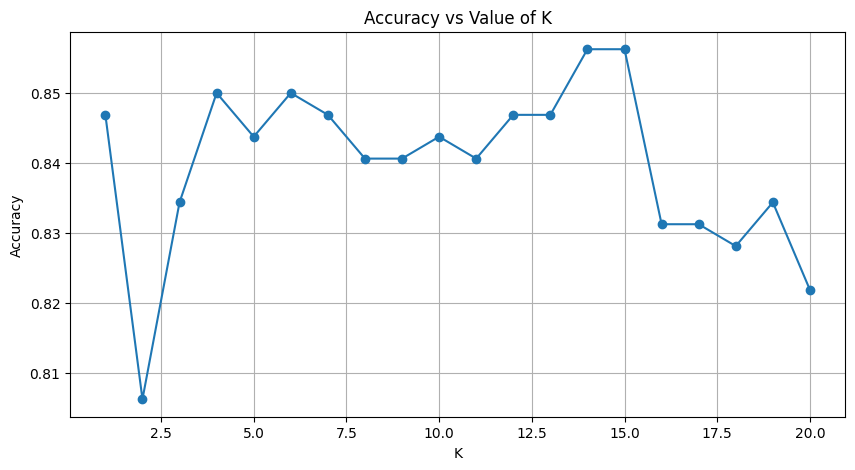

In [55]:
# 2. Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title("Accuracy vs Value of K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [56]:
# 3. Choose the best k
best_k = k_range[accuracies.index(max(accuracies))]
print(f"Best value of k: {best_k}")

Best value of k: 14


In [57]:
# 4. Train the final model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=14)

In [58]:
y_pred_final = final_knn.predict(X_test_scaled)

In [59]:
accuracy_score(y_test, y_pred_final)

0.85625

In [60]:
print("We get a little bit better accuracy score once we optimize the model")

We get a little bit better accuracy score once we optimize the model


### 5. Predict wine quality

In [ ]:
# 1. Function to predict wine quality

def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    pred = final_knn.predict(features_scaled)[0]
    if pred == 0:
        return "This wine is likely of low quality 🍷"
    elif pred == 1:
        return "This wine is likely of medium quality 🍷"
    else:
        return "This wine is likely of high quality 🍷"

In [63]:
# 2. Test the function
result = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,
                               11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print("\nExample prediction:", result)


Example prediction: This wine is likely of medium quality 🍷


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
